In [59]:
import warnings

import matplotlib.pyplot as plt
import pandas as pd

warnings.filterwarnings("ignore")

plt.rcParams.update(
    {"figure.figsize": (8, 5), "axes.facecolor": "white", "axes.edgecolor": "black"}
)
plt.rcParams["figure.facecolor"] = "w"
pd.plotting.register_matplotlib_converters()
pd.set_option("display.float_format", lambda x: "%.3f" % x)

In [60]:
df = pd.read_csv("data/eda.csv")

In [61]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 21597 entries, 0 to 21596
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21597 non-null  int64  
 1   bedrooms       21597 non-null  float64
 2   bathrooms      21597 non-null  float64
 3   sqft_living    21597 non-null  float64
 4   sqft_lot       21597 non-null  float64
 5   floors         21597 non-null  float64
 6   waterfront     19206 non-null  float64
 7   view           21534 non-null  float64
 8   condition      21597 non-null  int64  
 9   grade          21597 non-null  int64  
 10  sqft_above     21597 non-null  float64
 11  sqft_basement  21145 non-null  float64
 12  yr_built       21597 non-null  int64  
 13  yr_renovated   17749 non-null  float64
 14  zipcode        21597 non-null  int64  
 15  lat            21597 non-null  float64
 16  long           21597 non-null  float64
 17  sqft_living15  21597 non-null  float64
 18  sqft_lot15     21

In [62]:
df.columns

Index(['id', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors',
       'waterfront', 'view', 'condition', 'grade', 'sqft_above',
       'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode', 'lat', 'long',
       'sqft_living15', 'sqft_lot15', 'date', 'price'],
      dtype='str')

In [63]:
print(df['sqft_living'].head(5))
print(df['sqft_living15'].head(5))
print(df['sqft_lot'].head(5))
print(df['sqft_lot15'].head(5))

# sqft_living15 and sqft_lot15 contain different extra data, but it's unclear what they mean

0   1180.000
1   2570.000
2    770.000
3   1960.000
4   1680.000
Name: sqft_living, dtype: float64
0   1340.000
1   1690.000
2   2720.000
3   1360.000
4   1800.000
Name: sqft_living15, dtype: float64
0    5650.000
1    7242.000
2   10000.000
3    5000.000
4    8080.000
Name: sqft_lot, dtype: float64
0   5650.000
1   7639.000
2   8062.000
3   5000.000
4   7503.000
Name: sqft_lot15, dtype: float64


In [ ]:
df['date'] = pd.to_datetime(df['date'], format="%Y-%m-%d")


In [65]:
df['yr_renovated'] = df['yr_renovated'].astype(str).str.replace(r'0.$', '', regex=True)
df['yr_renovated'] = df['yr_renovated'].astype(str).str.replace(r'0.0$', '', regex=True)
df['yr_renovated'] = df['yr_renovated'].replace('', '0')
df['yr_renovated'] = df['yr_renovated'].astype('Int64')
df['yr_renovated'].unique()

<IntegerArray>
[   0, 1991, <NA>, 2002, 2010, 1992, 2013, 1994, 1978, 2005, 2003, 1984, 1954,
 2014, 2011, 1983, 1945, 1990, 1988, 1977, 1981, 1995, 2000, 1999, 1998, 1970,
 1989, 2004, 1986, 2007, 1987, 2006, 1985, 2001, 1980, 1971, 1979, 1997, 1950,
 1969, 1948, 2009, 2015, 1974, 2008, 1968, 2012, 1963, 1951, 1962, 1953, 1993,
 1996, 1955, 1982, 1956, 1940, 1976, 1946, 1975, 1964, 1973, 1957, 1959, 1960,
 1967, 1965, 1934, 1972, 1944, 1958]
Length: 71, dtype: Int64

In [74]:
df['waterfront'] = df['waterfront'].astype('Int64')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 21597 entries, 0 to 21596
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   id             21597 non-null  int64         
 1   bedrooms       21597 non-null  float64       
 2   bathrooms      21597 non-null  float64       
 3   sqft_living    21597 non-null  float64       
 4   sqft_lot       21597 non-null  float64       
 5   floors         21597 non-null  float64       
 6   waterfront     19206 non-null  Int64         
 7   view           21534 non-null  float64       
 8   condition      21597 non-null  int64         
 9   grade          21597 non-null  int64         
 10  sqft_above     21597 non-null  float64       
 11  sqft_basement  21145 non-null  float64       
 12  yr_built       21597 non-null  int64         
 13  yr_renovated   17749 non-null  Int64         
 14  zipcode        21597 non-null  int64         
 15  lat            21597 non-null 

In [75]:
#Calculate the median of sqft_living and create two groups: above and below median.
median_sqft = df['sqft_living'].median()
above_median = df[df['sqft_living'] >= median_sqft]
below_median = df[df['sqft_living'] < median_sqft]

In [76]:
print("Above median sqft_living:", above_median['price'].median())
print("Below median sqft_living:", below_median['price'].median())

Above median sqft_living: 600000.0
Below median sqft_living: 353000.0


In [77]:
import matplotlib.pyplot as plt
import seaborn as sns

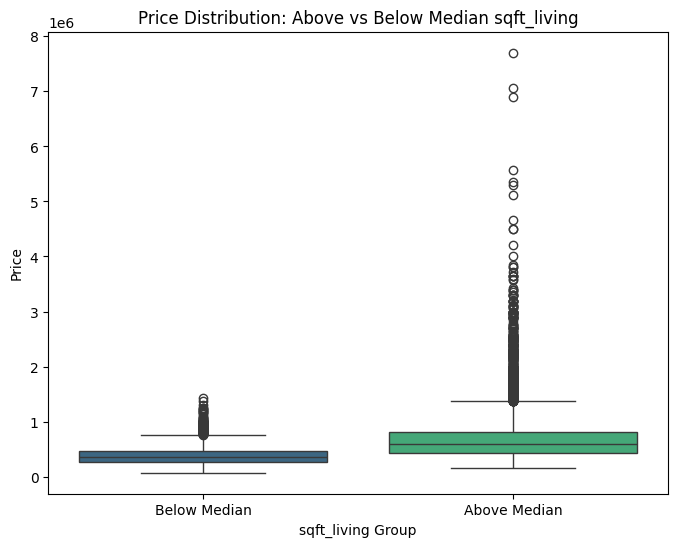

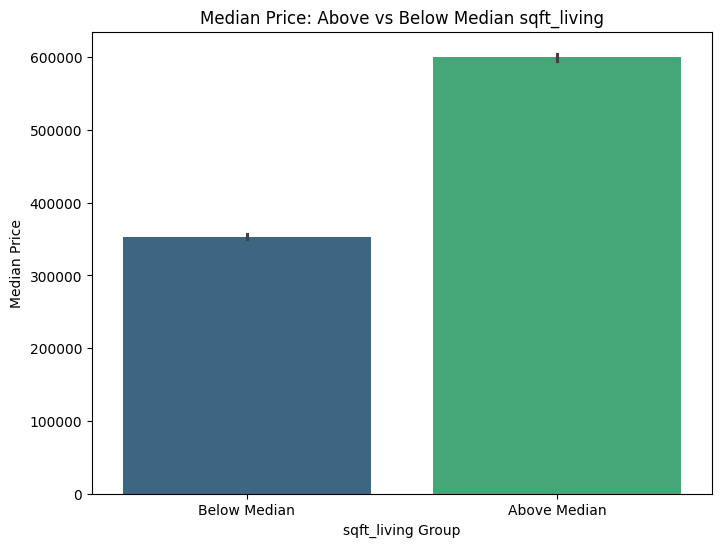

In [78]:
# Create a label column for the two groups
df['sqft_group'] = df['sqft_living'].apply(lambda x: 'Above Median' if x >= median_sqft else 'Below Median')

# Boxplot
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='sqft_group', y='price', palette='viridis')
plt.title('Price Distribution: Above vs Below Median sqft_living')
plt.xlabel('sqft_living Group')
plt.ylabel('Price')
plt.show()

# Barplot (median price per group)
plt.figure(figsize=(8, 6))
sns.barplot(data=df, x='sqft_group', y='price', estimator='median', palette='viridis')
plt.title('Median Price: Above vs Below Median sqft_living')
plt.xlabel('sqft_living Group')
plt.ylabel('Median Price')
plt.show()

In [80]:
def count_outliers(group):
    Q1 = group.quantile(0.25)
    Q3 = group.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = group[(group < lower) | (group > upper)]
    return len(outliers), lower, upper

for name, group in df.groupby('sqft_group')['price']:
    n_outliers, lower, upper = count_outliers(group)
    print(f"{name}:")
    print(f"  Outliers:    {n_outliers}")
    print(f"  Lower fence: ${lower:,.0f}")
    print(f"  Upper fence: ${upper:,.0f}")
    print()

Above Median:
  Outliers:    675
  Lower fence: $-135,000
  Upper fence: $1,377,000

Below Median:
  Outliers:    209
  Lower fence: $-35,000
  Upper fence: $765,000

